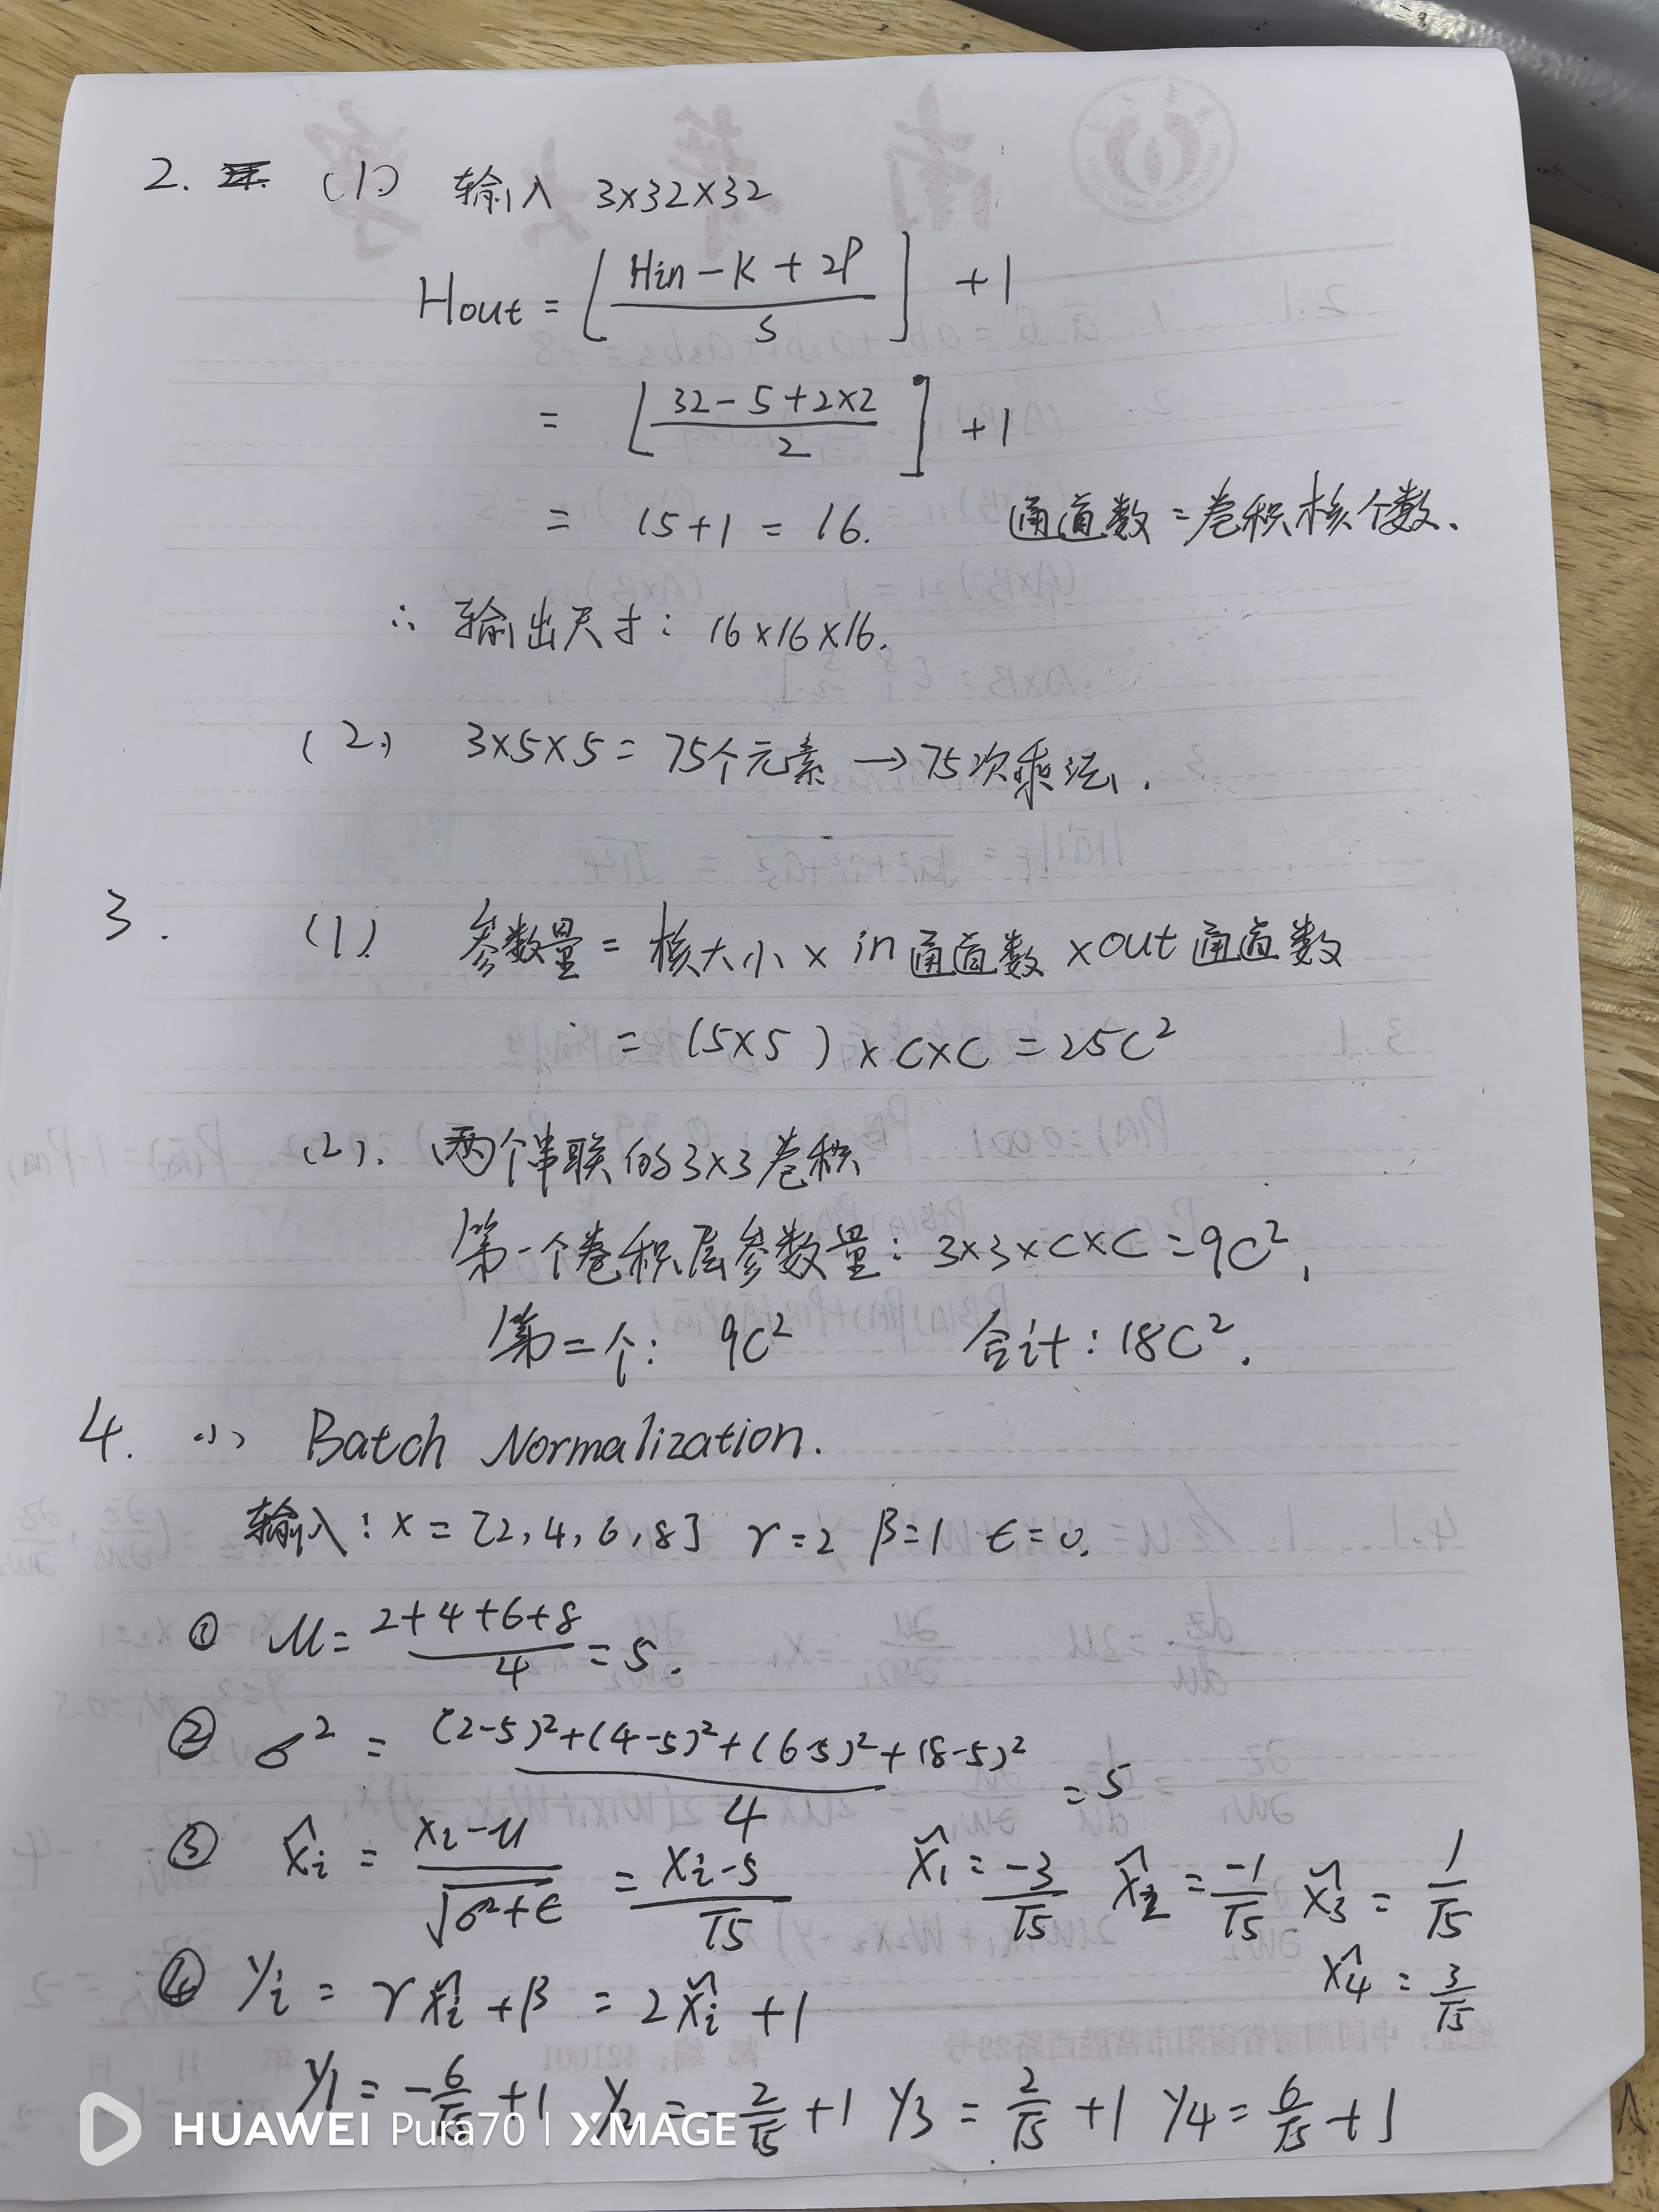

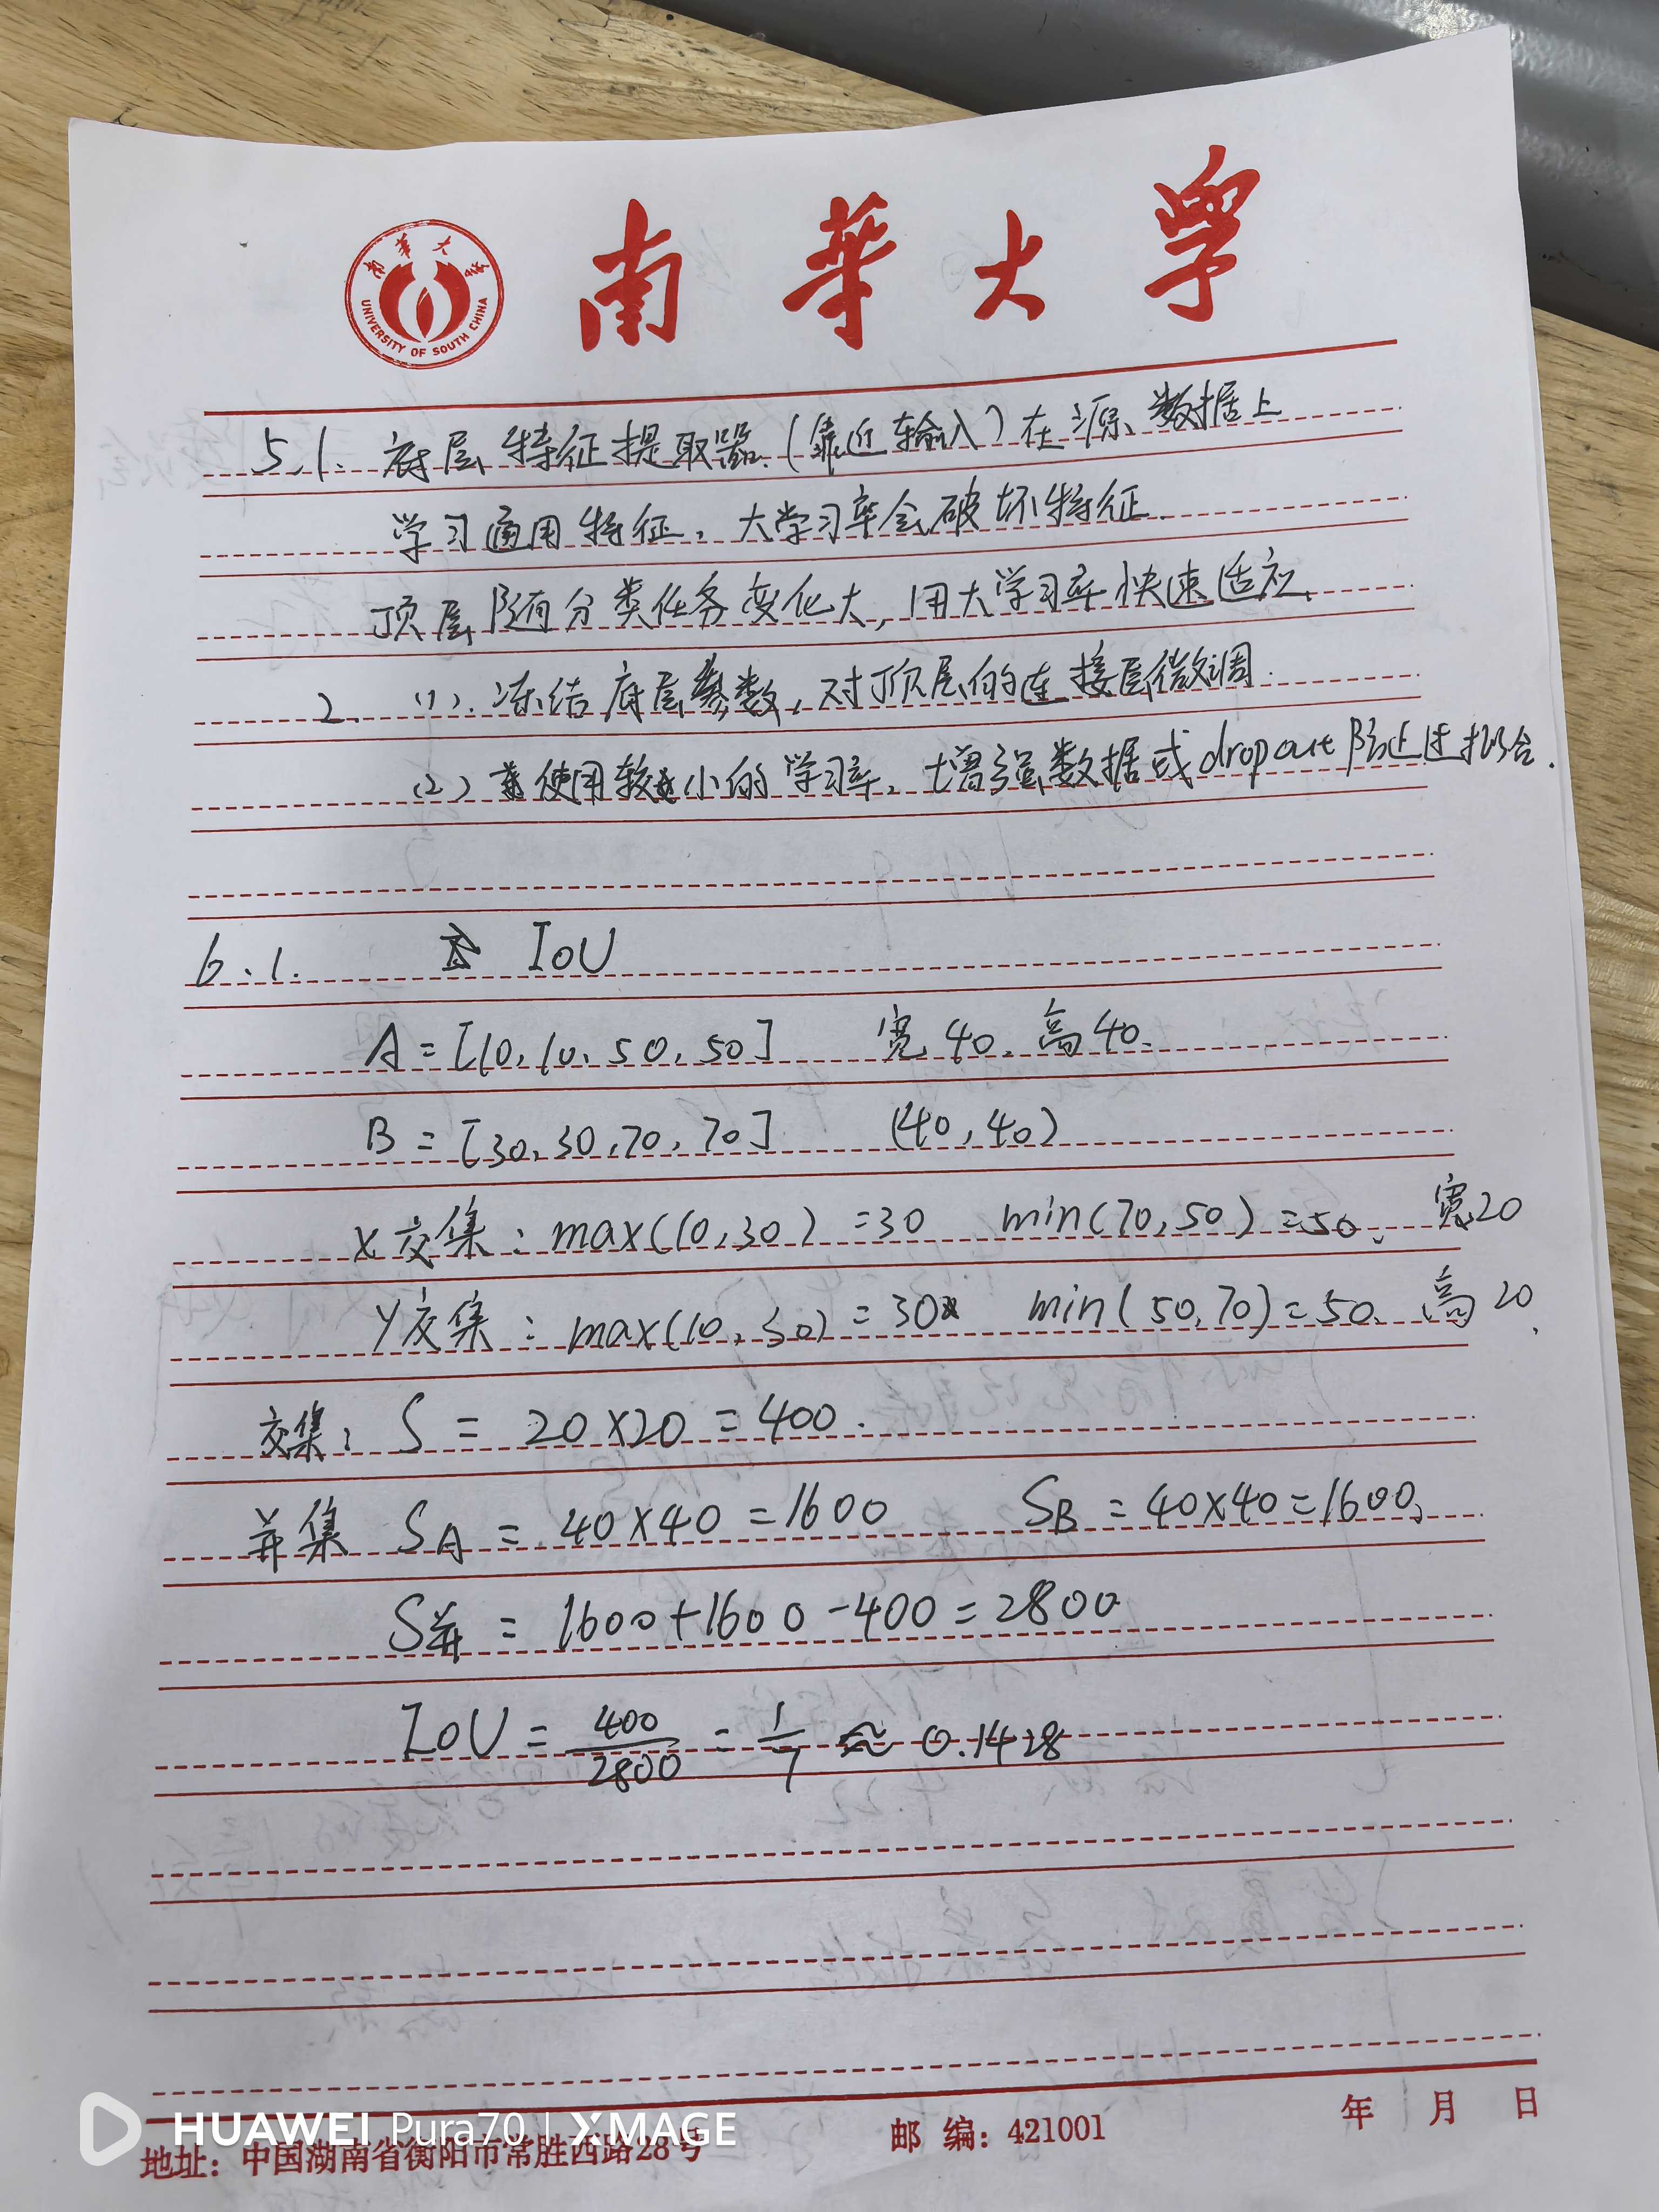

In [ ]:
#2.2
import numpy as np

def max_pool2d_forward(input, kernel_size, stride=None, padding=0):
    """
    二维最大池化前向传播（NumPy实现）
    
    参数:
        input: 输入张量，形状 (H, W) 或 (C, H, W) 或 (N, C, H, W)
        kernel_size: 池化核大小，int 或 (kh, kw)
        stride: 步长，int 或 (sh, sw)，默认等于 kernel_size
        padding: 填充大小，int 或 (ph, pw)，默认0
    
    返回:
        output: 池化后的张量
        mask: 最大值位置掩码（用于反向传播）
    """
    # 处理输入维度
    input_shape = input.shape
    ndim = len(input_shape)
    
    if ndim == 2:
        # (H, W) -> 添加批次数和通道数维度
        input_4d = input.reshape(1, 1, input_shape[0], input_shape[1])
        batch_size, channels = 1, 1
        original_shape = '2d'
    elif ndim == 3:
        # (C, H, W) -> 添加批次维度
        input_4d = input.reshape(1, input_shape[0], input_shape[1], input_shape[2])
        batch_size, channels = 1, input_shape[0]
        original_shape = '3d'
    elif ndim == 4:
        # (N, C, H, W)
        input_4d = input
        batch_size, channels = input_shape[0], input_shape[1]
        original_shape = '4d'
    else:
        raise ValueError(f"不支持的输入维度: {ndim}，支持 2D、3D 或 4D")
    
    N, C, H, W = input_4d.shape
    
    # 处理参数类型转换
    if isinstance(kernel_size, int):
        kh = kw = kernel_size
    else:
        kh, kw = kernel_size
    
    if stride is None:
        sh = sw = kh
    elif isinstance(stride, int):
        sh = sw = stride
    else:
        sh, sw = stride
    
    if isinstance(padding, int):
        ph = pw = padding
    else:
        ph, pw = padding
    
    # 添加填充
    input_padded = np.pad(input_4d, 
                          ((0, 0), (0, 0), (ph, ph), (pw, pw)),
                          mode='constant', constant_values=0)
    
    # 计算输出尺寸
    H_out = (H + 2*ph - kh) // sh + 1
    W_out = (W + 2*pw - kw) // sw + 1
    
    # 初始化输出和掩码
    output = np.zeros((N, C, H_out, W_out))
    mask = np.zeros_like(input_padded, dtype=bool)
    
    # 执行池化
    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    # 计算窗口位置
                    h_start = i * sh
                    h_end = h_start + kh
                    w_start = j * sw
                    w_end = w_start + kw
                    
                    # 提取窗口
                    window = input_padded[n, c, h_start:h_end, w_start:w_end]
                    
                    # 找到最大值及其位置
                    max_val = np.max(window)
                    output[n, c, i, j] = max_val
                    
                    # 记录最大值位置（用于反向传播）
                    # 注意：如果有多个相同最大值，只标记第一个
                    flat_idx = np.argmax(window)
                    max_pos = np.unravel_index(flat_idx, window.shape)
                    mask[n, c, h_start + max_pos[0], w_start + max_pos[1]] = True
    
    # 恢复原始形状
    if original_shape == '2d':
        output = output[0, 0]
        mask = mask[0, 0]
    elif original_shape == '3d':
        output = output[0]
        mask = mask[0]
    
    return output, mask

In [2]:
# 示例 1: 2D 输入
input_2d = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16]
])
output_2d, mask_2d = max_pool2d_forward(input_2d, kernel_size=2, stride=2, padding=0)
print("2D 输入池化结果:\n", output_2d)

# 示例 2: 带填充的 3D 输入 (C, H, W)
input_3d = np.random.randn(3, 8, 8)  # 3通道，8x8
output_3d, mask_3d = max_pool2d_forward(input_3d, kernel_size=3, stride=2, padding=1)
print(f"\n3D 输入输出形状: {input_3d.shape} -> {output_3d.shape}")

# 示例 3: 批量输入，不同步长和核大小
input_4d = np.random.randn(2, 4, 32, 32)  # 2个样本，4通道，32x32
output_4d, mask_4d = max_pool2d_forward(
    input_4d, 
    kernel_size=(3, 3), 
    stride=(2, 2), 
    padding=(1, 1)
)
print(f"\n4D 输入输出形状: {input_4d.shape} -> {output_4d.shape}")

2D 输入池化结果:
 [[ 6.  8.]
 [14. 16.]]

3D 输入输出形状: (3, 8, 8) -> (3, 4, 4)

4D 输入输出形状: (2, 4, 32, 32) -> (2, 4, 16, 16)


In [3]:
import torch
import torch.nn as nn
#验证与 PyTorch 结果一致

# NumPy 实现
np.random.seed(42)
input_np = np.random.randn(1, 1, 4, 4)

# PyTorch 实现
input_torch = torch.tensor(input_np, dtype=torch.float32)
pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
output_torch = pool(input_torch)

# 比较结果
output_np, _ = max_pool2d_forward(input_np, kernel_size=2, stride=2, padding=0)
print("NumPy 输出:\n", output_np[0, 0])
print("PyTorch 输出:\n", output_torch[0, 0])
print("是否一致:", np.allclose(output_np, output_torch.numpy()))

NumPy 输出:
 [[ 0.49671415  1.57921282]
 [ 0.54256004 -0.46341769]]
PyTorch 输出:
 tensor([[ 0.4967,  1.5792],
        [ 0.5426, -0.4634]])
是否一致: True


In [4]:
#3.2
import torch
import torch.nn as nn

class NiNBlock(nn.Module):
    """
    NiN 块（Network in Network Block）
    
    结构：普通卷积 -> ReLU -> 1x1卷积 -> ReLU -> 1x1卷积 -> ReLU
    
    参数：
        in_channels: 输入通道数
        out_channels: 输出通道数
        kernel_size: 第一个卷积层的核大小（默认 3）
        stride: 第一个卷积层的步幅（默认 1）
        padding: 第一个卷积层的填充（默认 0）
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=0):
        super(NiNBlock, self).__init__()
        
        self.block = nn.Sequential(
            # 第一个卷积层：普通卷积（可以是任意核大小）
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, 
                     stride=stride, padding=padding),
            nn.ReLU(inplace=True),
            
            # 第二个卷积层：1x1 卷积（相当于全连接层）
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU(inplace=True),
            
            # 第三个卷积层：1x1 卷积（进一步特征变换）
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.block(x)


# 使用示例
if __name__ == "__main__":
    # 创建 NiN 块
    nin_block = NiNBlock(in_channels=3, out_channels=96, kernel_size=3, stride=1, padding=1)
    
    # 测试前向传播
    x = torch.randn(1, 3, 224, 224)
    output = nin_block(x)
    print(f"输入形状: {x.shape}")
    print(f"输出形状: {output.shape}")
    print(f"参数量: {sum(p.numel() for p in nin_block.parameters()):,}")

输入形状: torch.Size([1, 3, 224, 224])
输出形状: torch.Size([1, 96, 224, 224])
参数量: 21,312


In [5]:
#4.2
import torch
import torch.nn as nn

class Residual(nn.Module):
    """
    残差块（Residual Block）
    
    结构：卷积(3x3) -> BN -> ReLU -> 卷积(3x3) -> BN -> (+ 残差连接) -> ReLU
    
    参数：
        in_channels: 输入通道数
        out_channels: 输出通道数
        use_1x1conv: 是否使用1x1卷积调整残差连接（当输入输出维度不匹配时为True）
        stride: 第一个卷积层的步幅（默认1）
    """
    def __init__(self, in_channels, out_channels, use_1x1conv=False, stride=1):
        super(Residual, self).__init__()
        
        # 第一个卷积层：3x3，步幅为stride，用于下采样
        self.conv1 = nn.Conv2d(in_channels, out_channels, 
                               kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # 第二个卷积层：3x3，步幅为1，保持特征图大小
        self.conv2 = nn.Conv2d(out_channels, out_channels, 
                               kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # 残差连接：如果use_1x1conv=True，使用1x1卷积调整输入维度
        if use_1x1conv:
            self.shortcut = nn.Conv2d(in_channels, out_channels, 
                                      kernel_size=1, stride=stride)
        else:
            self.shortcut = None
        
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        # 残差路径
        residual = x if self.shortcut is None else self.shortcut(x)
        
        # 主路径
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        # 残差连接（按元素相加）
        out += residual
        
        # 最终激活
        out = self.relu(out)
        
        return out


# 使用示例
if __name__ == "__main__":
    # 示例1：输入输出通道相同，无1x1卷积
    block1 = Residual(in_channels=64, out_channels=64, use_1x1conv=False)
    x1 = torch.randn(1, 64, 56, 56)
    out1 = block1(x1)
    print(f"输入形状: {x1.shape}")
    print(f"输出形状: {out1.shape}")
    print(f"参数量: {sum(p.numel() for p in block1.parameters()):,}\n")
    
    # 示例2：输入输出通道不同，使用1x1卷积
    block2 = Residual(in_channels=64, out_channels=128, use_1x1conv=True, stride=2)
    x2 = torch.randn(1, 64, 56, 56)
    out2 = block2(x2)
    print(f"输入形状: {x2.shape}")
    print(f"输出形状: {out2.shape}")
    print(f"参数量: {sum(p.numel() for p in block2.parameters()):,}\n")
    
    # 示例3：构建简单的ResNet块堆叠
    class SimpleResNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
            self.bn1 = nn.BatchNorm2d(64)
            self.relu = nn.ReLU(inplace=True)
            self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
            
            # ResNet-34 的第一个残差块组
            self.layer1 = nn.Sequential(
                Residual(64, 64, use_1x1conv=False),
                Residual(64, 64, use_1x1conv=False),
                Residual(64, 64, use_1x1conv=False)
            )
            
            self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
            self.fc = nn.Linear(64, 1000)
        
        def forward(self, x):
            x = self.conv1(x)
            x = self.bn1(x)
            x = self.relu(x)
            x = self.maxpool(x)
            x = self.layer1(x)
            x = self.avgpool(x)
            x = torch.flatten(x, 1)
            x = self.fc(x)
            return x
    
    model = SimpleResNet()
    x3 = torch.randn(1, 3, 224, 224)
    out3 = model(x3)
    print(f"完整ResNet输入: {x3.shape} -> 输出: {out3.shape}")

输入形状: torch.Size([1, 64, 56, 56])
输出形状: torch.Size([1, 64, 56, 56])
参数量: 74,112

输入形状: torch.Size([1, 64, 56, 56])
输出形状: torch.Size([1, 128, 28, 28])
参数量: 230,272

完整ResNet输入: torch.Size([1, 3, 224, 224]) -> 输出: torch.Size([1, 1000])


In [6]:
#5.2
import torchvision.transforms as transforms

# 创建组合图像增广管道
transform_pipeline = transforms.Compose([
    # 1. 随机裁剪并缩放到224x224
    #    scale: 裁剪面积比例范围 [0.08, 1.0]
    #    ratio: 裁剪宽高比范围，默认 [3/4, 4/3]
    transforms.RandomResizedCrop(size=224, scale=(0.08, 1.0)),
    
    # 2. 50%概率水平翻转
    transforms.RandomHorizontalFlip(p=0.5),
    
    # 3. 随机改变亮度、对比度、饱和度
    #    brightness, contrast, saturation 的范围为 [0.5, 1.5]
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    
    # 4. 转换为PyTorch张量（自动将像素值归一化到[0,1]）
    transforms.ToTensor()
])

# 使用示例
if __name__ == "__main__":
    from PIL import Image
    import torch
    
    # 加载示例图像
    # img = Image.open("example.jpg").convert("RGB")
    
    # 创建示例图像（用于演示）
    img = Image.new('RGB', (500, 400), color='red')
    
    # 应用增广管道
    augmented_img = transform_pipeline(img)
    
    print(f"增广后张量形状: {augmented_img.shape}")  # 预期: torch.Size([3, 224, 224])
    print(f"像素值范围: [{augmented_img.min():.3f}, {augmented_img.max():.3f}]")
    
    # 可选：多次应用查看效果
    print("\n多次应用增广的效果:")
    for i in range(3):
        img_aug = transform_pipeline(img)
        print(f"  第{i+1}次: 形状={img_aug.shape}, 均值={img_aug.mean():.3f}")

增广后张量形状: torch.Size([3, 224, 224])
像素值范围: [0.000, 0.627]

多次应用增广的效果:
  第1次: 形状=torch.Size([3, 224, 224]), 均值=0.318
  第2次: 形状=torch.Size([3, 224, 224]), 均值=0.324
  第3次: 形状=torch.Size([3, 224, 224]), 均值=0.399


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LabelSmoothingCrossEntropy(nn.Module):
    """
    标签平滑交叉熵损失函数
    公式：
    真实类目标概率: 1 - ε
    其余类目标概率: ε/(K-1)
    """
    def __init__(self, eps=0.1, num_classes=1000):
        super().__init__()
        self.eps = eps          # 平滑因子 ε
        self.num_classes = num_classes  # 分类总数 K
        # 平滑后非真实标签的概率值
        self.smooth_val = eps / (num_classes - 1)

    def forward(self, inputs, targets):
        """
        前向传播计算损失
        :param inputs: 模型输出 logits (形状: [batch_size, num_classes])
        :param targets: 真实标签 (形状: [batch_size])
        :return: 标签平滑后的交叉熵损失
        """
        # 1. 计算基础交叉熵损失（不带平滑）
        log_probs = F.log_softmax(inputs, dim=-1)
        
        # 2. 构造标签平滑后的目标分布
        batch_size = inputs.size(0)
        # 初始化目标分布: 所有类别概率 = smooth_val
        smooth_targets = torch.full_like(inputs, self.smooth_val)
        # 真实类别位置赋值: 1 - eps
        smooth_targets.scatter_(dim=1, index=targets.unsqueeze(1), value=1. - self.eps)
        
        # 3. 计算标签平滑交叉熵：-sum(目标分布 * 对数概率) / 批次大小
        loss = (-smooth_targets * log_probs).sum(dim=-1).mean()
        return loss


#测试函数
def test_label_smoothing():
    # 超参数
    eps = 0.1
    num_classes = 5  # 5分类问题
    batch_size = 2

    # 模拟模型输出 logits（未经过softmax）
    inputs = torch.randn(batch_size, num_classes)
    # 模拟真实标签 [0, 3]
    targets = torch.tensor([0, 3], dtype=torch.long)

    # 初始化损失函数
    criterion = LabelSmoothingCrossEntropy(eps=eps, num_classes=num_classes)
    # 计算损失
    loss = criterion(inputs, targets)
    
    print("="*50)
    print(f"平滑因子 ε = {eps}")
    print(f"分类数 K = {num_classes}")
    print(f"真实标签概率 = {1-eps}")
    print(f"其余标签概率 = {eps/(num_classes-1):.4f}")
    print(f"标签平滑交叉熵损失 = {loss.item():.4f}")
    print("="*50)

if __name__ == "__main__":
    test_label_smoothing()

平滑因子 ε = 0.1
分类数 K = 5
真实标签概率 = 0.9
其余标签概率 = 0.0250
标签平滑交叉熵损失 = 2.0765
